# EMPOT Iterative Subtomogram Averaging

This notebook performs iterative alignment and subtomogram averaging on the 200 subtomograms in `Data/0.1/Cluster_0`.

Instead of just recovering rotation (as in AlignOT), this workflow uses **EMPOT** (Unbalanced Gromov-Wasserstein Optimal Transport + Kabsch SVD) to recover **both rotation and translation** for each subtomogram. The full original volume is then transformed and averaged into a new reference.

Workflow summary:
- Compute the initial reference as the plain average of the original subtomograms.
- For each round:
  - Sample the reference point cloud once.
  - For each subtomogram:
    - Sample its point cloud.
    - Recover both rotation and translation aligning the subtomogram to the reference.
    - Apply the recovered rigid transformation to the **full original subtomogram volume** using `scipy.ndimage.affine_transform`.
    - Accumulate the transformed volumes.
  - Form the next-round reference.

Important memory safety rules enforced here:
- Every round always reloads and aligns the **original** subtomogram files.
- No previously transformed subtomogram is reused as the next round's alignment input.
- Aggressive garbage collection (`gc.collect()`) is used to prevent memory leaks.

In [7]:
%matplotlib inline

import sys
import os
import contextlib
import io
import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mrcfile
import torch
from scipy.ndimage import affine_transform
from scipy.spatial.transform import Rotation

# Add EMPOT/src to path for trn and coords imports
sys.path.insert(0, os.path.abspath('../src'))
import trn

from unbalancedgw.vanilla_ugw_solver import log_ugw_sinkhorn
from unbalancedgw._vanilla_utils import l2_distortion

plt.rcParams["figure.figsize"] = (12, 4)
plt.style.use("default")

In [8]:
cluster_dir = Path("../../Data/0.1/Cluster_0")
output_dir = Path("iterative_alignment_outputs_cluster0")

n_subtomograms = 200
n_rounds = 2

# Sampling hyperparameters
threshold = 0.7
num_points = 500

# EMPOT UGW hyperparameters
eps = 10000
rho = 100000
rho2 = 100000
nits_plan = 100
nits_sinkhorn = 100

experiment_seed = 42
cleanup_every = 10
progress_every = 10

output_dir.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {cluster_dir.resolve()}")
print(f"Output directory: {output_dir.resolve()}")

Data directory: /home/anshu/subtmgr-align/Data/0.1/Cluster_0
Output directory: /home/anshu/subtmgr-align/EMPOT/notebooks/iterative_alignment_outputs_cluster0


In [9]:
def get_cluster_paths(cluster_dir, n_expected=200):
    cluster_dir = Path(cluster_dir)
    paths = [path for path in cluster_dir.iterdir() if path.is_file() and path.suffix == ".mrc" and "Zone" not in path.name]
    paths = sorted(paths, key=lambda path: int(path.stem))
    if n_expected is not None and len(paths) != n_expected:
        print(f"Warning: Expected {n_expected} .mrc files, found {len(paths)} in {cluster_dir}")
    return paths

def load_mrc(path, permissive=False):
    with mrcfile.open(path, permissive=permissive) as mrc:
        return np.array(mrc.data, dtype=np.float32)

def save_mrc(path, arr):
    arr = np.asarray(arr, dtype=np.float32)
    with mrcfile.new(path, overwrite=True) as mrc:
        mrc.set_data(arr)
    return Path(path)

def compute_streaming_average(paths, progress_every=20):
    total = None
    count = 0
    for idx, path in enumerate(paths, start=1):
        arr = load_mrc(path, permissive=True)
        if total is None:
            total = np.zeros_like(arr, dtype=np.float64)
        total += arr
        count += 1
        if progress_every and (idx % progress_every == 0 or idx == len(paths)):
            print(f"Initial averaging: loaded {idx}/{len(paths)} subtomograms")
        del arr
        if progress_every and idx % progress_every == 0:
            gc.collect()
    if count == 0:
        raise ValueError("Cannot compute an average from zero subtomograms.")
    return (total / count).astype(np.float32)

def show_volume_slices(volume, title_prefix):
    volume = np.asarray(volume, dtype=np.float32)
    mid_z = volume.shape[0] // 2
    mid_y = volume.shape[1] // 2
    mid_x = volume.shape[2] // 2
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(volume[mid_z, :, :], cmap="gray")
    axes[0].set_title(f"{title_prefix}: XY")
    axes[1].imshow(volume[:, mid_y, :], cmap="gray")
    axes[1].set_title(f"{title_prefix}: XZ")
    axes[2].imshow(volume[:, :, mid_x], cmap="gray")
    axes[2].set_title(f"{title_prefix}: YZ")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    return fig, axes

def reference_change_stats(prev_ref, next_ref, round_idx):
    diff = np.asarray(next_ref, dtype=np.float32) - np.asarray(prev_ref, dtype=np.float32)
    return {
        "round": int(round_idx),
        "reference_l2_change": float(np.linalg.norm(diff)),
        "reference_mean_abs_change": float(np.mean(np.abs(diff))),
        "reference_max_abs_change": float(np.max(np.abs(diff))),
    }

In [10]:
def normalize_volume(volume):
    """Normalize a 3D volume to [0, 1]."""
    volume = volume.astype(np.float32)
    volume = volume - volume.min()
    vmax = float(volume.max())
    if vmax <= 0:
        raise ValueError("Volume is constant after normalization.")
    return volume / (vmax + 1e-8)

def prepare_sampling_volume(volume):
    """Normalize and invert volume (dark-is-signal) for sampling."""
    norm = normalize_volume(volume)
    return 1.0 - norm

def sample_volume_in_memory(prepared_volume, threshold, num_points, random_seed=None):
    """
    Sample pseudo-atoms from a normalized volume using TRN.
    Returns an (M, 3) numpy array of point coordinates (voxel-index space).
    """
    map_th = np.asarray(prepared_volume, dtype=np.float32).copy()
    map_th[map_th < threshold] = 0
    if float(map_th.sum()) <= 0:
        raise ValueError(f"Threshold {threshold} zeroes out the entire volume.")

    with contextlib.redirect_stdout(io.StringIO()):
        rm0, arr_flat, arr_idx, xyz, coords_1d = trn.trn_rm0(
            map_th, M=num_points, random_seed=random_seed,
        )
        rms, rs, ts_save = trn.trn_iterate(
            rm0, arr_flat, arr_idx, xyz,
            n_save=10, e0=0.3, ef=0.05,
            l0=0.005 * num_points, lf=0.5,
            tf=num_points * 8,
            do_log=True, log_n=10,
        )
    return rms[-1]  # shape (M, 3)

def run_empot_alignment(pts_ref, pts_tgt,
                         eps=2000, rho=100000, rho2=100000,
                         nits_plan=100, nits_sinkhorn=100):
    """
    Run the full EMPOT alignment pipeline: UGW -> correspondences -> Kabsch SVD.
    Returns: Abar, Bbar, R_recovered, dist
    """
    n_ref = len(pts_ref)
    n_tgt = len(pts_tgt)

    a = np.ones(n_ref) / n_ref
    b = np.ones(n_tgt) / n_tgt

    dx = np.sum((pts_ref[:, None, :] - pts_ref[None, :, :]) ** 2, axis=-1)
    dy = np.sum((pts_tgt[:, None, :] - pts_tgt[None, :, :]) ** 2, axis=-1)

    a_t = torch.from_numpy(a)
    b_t = torch.from_numpy(b)
    dx_t = torch.from_numpy(dx)
    dy_t = torch.from_numpy(dy)

    pi, gamma = log_ugw_sinkhorn(
        a_t, dx_t, b_t, dy_t, init=None, eps=eps,
        rho=rho, rho2=rho2,
        nits_plan=nits_plan, tol_plan=1e-10,
        nits_sinkhorn=nits_sinkhorn, tol_sinkhorn=1e-10,
        two_outputs=True,
    )

    dist = float(l2_distortion(pi, gamma, dx_t, dy_t))

    pi_np = np.array(pi)
    all_coup = []
    for i in range(n_tgt):
        j = int(np.argmax(pi_np[:, i]))
        if pi_np[j, i] > 0:
            all_coup.append((i, j))

    A = np.array([pts_ref[c[1]] for c in all_coup])
    B = np.array([pts_tgt[c[0]] for c in all_coup])

    Abar = A.mean(axis=0)
    Bbar = B.mean(axis=0)

    H = (A - Abar).T @ (B - Bbar)
    U, S, V = np.linalg.svd(H)

    d = np.linalg.det(U @ V)
    R = U @ np.diag([1.0, 1.0, d]) @ V

    R_recovered = Rotation.from_matrix(R)
    return Abar, Bbar, R_recovered, dist

def apply_rigid_transform_to_volume(volume, R_rec, Abar, Bbar):
    """
    Transforms a 3D target volume so that its contents align with the reference volume.
    
    EMPOT computes Abar, Bbar, R_rec such that:
    (Reference - Abar) ≈ R_rec @ (Target - Bbar)
    
    For scipy.ndimage.affine_transform, the transformation maps output indices to input indices:
    input_idx = matrix @ output_idx + offset
    
    Since TRN sampled points perfectly map to numpy array indices [z, y, x] offset by N/2,
    we can algebraically derive the exact matrix and offset required for affine_transform.
    """
    N = volume.shape[0]
    center = np.array([N/2.0, N/2.0, N/2.0])
    
    # We want a matrix that maps output (reference) coords back to input (target) coords.
    R_inv_mat = R_rec.inv().as_matrix()
    
    # Derived offset to account for center and centroids
    offset = Bbar + center - R_inv_mat @ (Abar + center)
    
    return affine_transform(volume, R_inv_mat, offset=offset, order=3, mode='constant', cval=0.0)


Discovered 200 subtomograms in ../../Data/0.1/Cluster_0
Initial averaging: loaded 10/200 subtomograms
Initial averaging: loaded 20/200 subtomograms
Initial averaging: loaded 30/200 subtomograms
Initial averaging: loaded 40/200 subtomograms
Initial averaging: loaded 50/200 subtomograms
Initial averaging: loaded 60/200 subtomograms
Initial averaging: loaded 70/200 subtomograms
Initial averaging: loaded 80/200 subtomograms
Initial averaging: loaded 90/200 subtomograms
Initial averaging: loaded 100/200 subtomograms
Initial averaging: loaded 110/200 subtomograms
Initial averaging: loaded 120/200 subtomograms
Initial averaging: loaded 130/200 subtomograms
Initial averaging: loaded 140/200 subtomograms
Initial averaging: loaded 150/200 subtomograms
Initial averaging: loaded 160/200 subtomograms
Initial averaging: loaded 170/200 subtomograms
Initial averaging: loaded 180/200 subtomograms
Initial averaging: loaded 190/200 subtomograms
Initial averaging: loaded 200/200 subtomograms
Saved initial

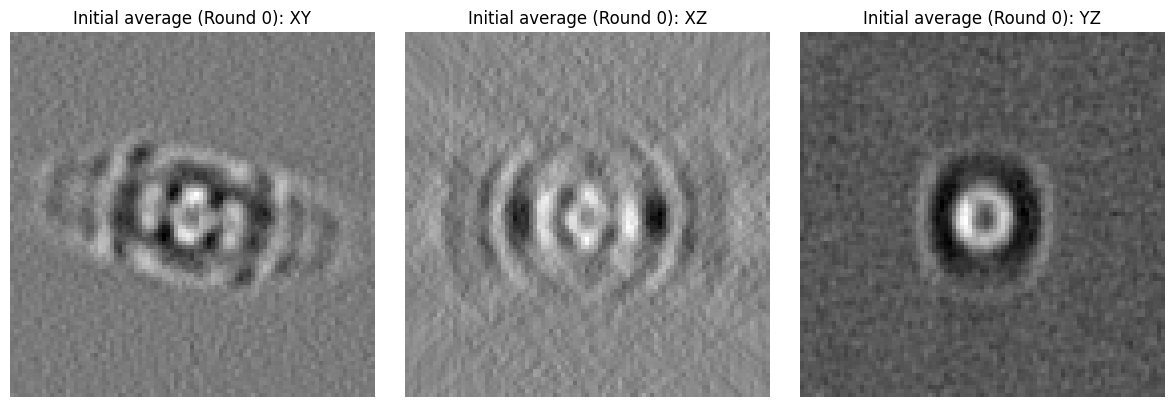

In [ ]:
cluster_paths = get_cluster_paths(cluster_dir, n_expected=n_subtomograms)
print(f"Discovered {len(cluster_paths)} subtomograms in {cluster_dir}")

reference_round_00 = compute_streaming_average(cluster_paths, progress_every=progress_every)
reference_round_00_path = save_mrc(output_dir / "reference_round_00.mrc", reference_round_00)
print(f"Saved initial reference to: {reference_round_00_path}")

fig, axes = show_volume_slices(reference_round_00, "Initial average (Round 0)")
plt.show()

In [12]:
current_reference = reference_round_00.copy()
round_metrics = []
round_reference_paths = [reference_round_00_path]

for round_idx in range(1, n_rounds + 1):
    print(f"\n{'='*40}")
    print(f"Starting round {round_idx}/{n_rounds}")
    print(f"{'='*40}")
    round_start = time.perf_counter()

    # 1. Prepare and sample the reference
    reference_sampling_volume = prepare_sampling_volume(current_reference)
    pts_ref = sample_volume_in_memory(
        reference_sampling_volume,
        threshold=threshold,
        num_points=num_points,
        random_seed=experiment_seed + 1000 * round_idx,
    )

    sum_transformed = np.zeros_like(current_reference, dtype=np.float64)
    count = 0
    subtomogram_rows = []

    # 2. Iterate over all subtomograms
    for item_idx, path in enumerate(cluster_paths, start=1):
        subtomogram_start = time.perf_counter()
        
        # Load the original unaligned volume
        volume = load_mrc(path, permissive=True)
        
        # Prepare and sample the subtomogram
        sampling_volume = prepare_sampling_volume(volume)
        pts_tgt = sample_volume_in_memory(
            sampling_volume,
            threshold=threshold,
            num_points=num_points,
            random_seed=experiment_seed + round_idx + count,
        )

        # 3. Align subtomogram to reference using EMPOT
        Abar, Bbar, R_recovered, dist = run_empot_alignment(
            pts_ref, pts_tgt,
            eps=eps, rho=rho, rho2=rho2,
            nits_plan=nits_plan, nits_sinkhorn=nits_sinkhorn
        )
        
        # 4. Transform the full volume with rotation AND translation
        transformed_volume = apply_rigid_transform_to_volume(volume, R_recovered, Abar, Bbar)

        # 5. Accumulate
        sum_transformed += transformed_volume
        count += 1
        runtime_s = time.perf_counter() - subtomogram_start
        
        subtomogram_rows.append({
            "round": round_idx,
            "subtomogram_id": int(path.stem),
            "file_name": path.name,
            "runtime_s": float(runtime_s),
            "ugw_dist": float(dist),
        })

        if progress_every and (item_idx % progress_every == 0 or item_idx == len(cluster_paths)):
            print(f"  Round {round_idx}: aligned {item_idx}/{len(cluster_paths)} subtomograms")

        # Memory cleanup
        del volume, sampling_volume, pts_tgt, transformed_volume, R_recovered
        if cleanup_every and item_idx % cleanup_every == 0:
            gc.collect()

    # 6. Form next reference
    next_reference = (sum_transformed / count).astype(np.float32)
    reference_path = save_mrc(output_dir / f"reference_round_{round_idx:02d}.mrc", next_reference)
    round_reference_paths.append(reference_path)

    # 7. Metrics tracking
    round_df = pd.DataFrame(subtomogram_rows)
    change_row = reference_change_stats(current_reference, next_reference, round_idx)
    change_row.update({
        "n_subtomograms": int(count),
        "mean_runtime_s": float(round_df["runtime_s"].mean()),
        "mean_ugw_dist": float(round_df["ugw_dist"].mean()),
        "reference_path": str(reference_path),
        "round_runtime_s": float(time.perf_counter() - round_start),
    })
    round_metrics.append(change_row)

    # Prepare for next round
    current_reference = next_reference
    del reference_sampling_volume, pts_ref, sum_transformed, round_df, subtomogram_rows, next_reference
    gc.collect()
    print(f"Completed round {round_idx}; saved reference to: {reference_path}")



Starting round 1/2
  Round 1: aligned 10/200 subtomograms
  Round 1: aligned 20/200 subtomograms
  Round 1: aligned 30/200 subtomograms
  Round 1: aligned 40/200 subtomograms
  Round 1: aligned 50/200 subtomograms
  Round 1: aligned 60/200 subtomograms
  Round 1: aligned 70/200 subtomograms
  Round 1: aligned 80/200 subtomograms
  Round 1: aligned 90/200 subtomograms
  Round 1: aligned 100/200 subtomograms
  Round 1: aligned 110/200 subtomograms
  Round 1: aligned 120/200 subtomograms
  Round 1: aligned 130/200 subtomograms
  Round 1: aligned 140/200 subtomograms
  Round 1: aligned 150/200 subtomograms
  Round 1: aligned 160/200 subtomograms
  Round 1: aligned 170/200 subtomograms
  Round 1: aligned 180/200 subtomograms
  Round 1: aligned 190/200 subtomograms
  Round 1: aligned 200/200 subtomograms
Completed round 1; saved reference to: iterative_alignment_outputs_cluster0/reference_round_01.mrc

Starting round 2/2
  Round 2: aligned 10/200 subtomograms
  Round 2: aligned 20/200 subto

In [13]:
round_metrics_df = pd.DataFrame(round_metrics, columns=[
    "round",
    "n_subtomograms",
    "mean_runtime_s",
    "mean_ugw_dist",
    "reference_l2_change",
    "reference_mean_abs_change",
    "reference_max_abs_change",
    "reference_path",
    "round_runtime_s",
])
round_metrics_path = output_dir / "round_metrics.csv"
round_metrics_df.to_csv(round_metrics_path, index=False)
print(f"Saved round metrics to: {round_metrics_path}")
round_metrics_df

Saved round metrics to: iterative_alignment_outputs_cluster0/round_metrics.csv


,round,n_subtomograms,mean_runtime_s,mean_ugw_dist,reference_l2_change,reference_mean_abs_change,reference_max_abs_change,reference_path,round_runtime_s
0,1,200,6.363504,5900.492326,96.142776,0.081684,1.209776,iterative_alignment_outputs_cluster0/reference...,1274.263256
1,2,200,11.630975,10492.927123,81.455826,0.068568,0.861757,iterative_alignment_outputs_cluster0/reference...,2327.822548


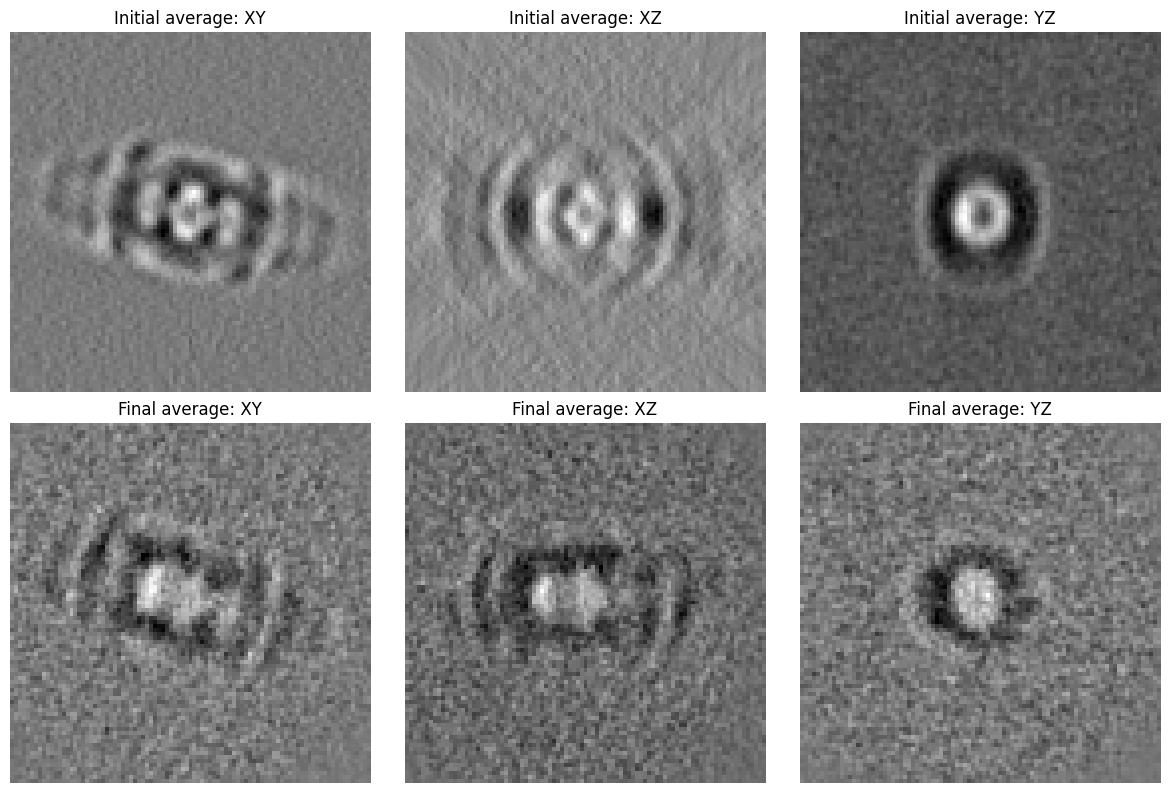

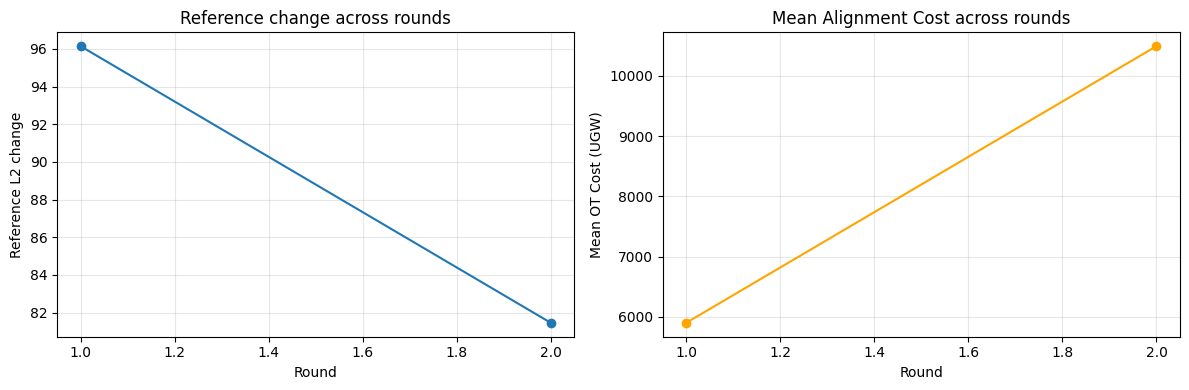

In [14]:
final_reference = current_reference

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
initial_mid_z = reference_round_00.shape[0] // 2
initial_mid_y = reference_round_00.shape[1] // 2
initial_mid_x = reference_round_00.shape[2] // 2
final_mid_z = final_reference.shape[0] // 2
final_mid_y = final_reference.shape[1] // 2
final_mid_x = final_reference.shape[2] // 2

axes[0, 0].imshow(reference_round_00[initial_mid_z, :, :], cmap="gray")
axes[0, 0].set_title("Initial average: XY")
axes[0, 1].imshow(reference_round_00[:, initial_mid_y, :], cmap="gray")
axes[0, 1].set_title("Initial average: XZ")
axes[0, 2].imshow(reference_round_00[:, :, initial_mid_x], cmap="gray")
axes[0, 2].set_title("Initial average: YZ")

axes[1, 0].imshow(final_reference[final_mid_z, :, :], cmap="gray")
axes[1, 0].set_title("Final average: XY")
axes[1, 1].imshow(final_reference[:, final_mid_y, :], cmap="gray")
axes[1, 1].set_title("Final average: XZ")
axes[1, 2].imshow(final_reference[:, :, final_mid_x], cmap="gray")
axes[1, 2].set_title("Final average: YZ")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(round_metrics_df["round"], round_metrics_df["reference_l2_change"], marker="o")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Reference L2 change")
axes[0].set_title("Reference change across rounds")
axes[0].grid(True, alpha=0.3)

axes[1].plot(round_metrics_df["round"], round_metrics_df["mean_ugw_dist"], marker="o", color="orange")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Mean OT Cost (UGW)")
axes[1].set_title("Mean Alignment Cost across rounds")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()